## SQL Interview Questions:-

### Q. What are the types of SQL Commands?
- **Types of SQL Commands**:-
    1. **DDL - Data Definition Language**:- DDL consists of SQL commands that can be used for defining, altering and deleting database structures such as tables, indexes and schemas.
        - **Commands**:- Create, Alter, Drop, Truncate, Rename.
    2. **DML - Data Manipulation Language**:- DML commands are used to manipulate the data stored in database tables. With DML, you can insert new records, update existing ones, delete unwanted data or retrieve information.
        - **Commands**:- Insert, Merge, Delete, Update
    3. **DQL - Data Query Language**:- DQL is used to fetch data from the database. The main command is SELECT, which retrieves records based on the query.
        - **Command**:- SELECT.   
    4. **TCL - Transactional Control Language**:- Transactions group a set of tasks into a single execution unit. Each transaction begins with a specific task and ends when all the tasks in the group are successfully completed. If any of the tasks fail, transaction fails. Therefore, a transaction has only two results: success or failure.
        - **Commands**:- Commit, Roleback, Savepoint.
    5. **DCL - Data Control Language**:- DCL includes commands such as GRANT and REVOKE which mainly deal with the rights, permissions and other controls of the database system. These commands are used to control access to data in the database by granting or revoking permissions.
        - **Commands**:- Grant, Revoke
- **Quick Memory Tricks**:-
    1. DDL → Structure (Table banata hai).
    2. DML → Data change karta hai.
    3. DQL → Data fetch karta hai.
    4. TCL → Transaction control karta hai.
    5. DCL → Permission control karta hai.
       
- 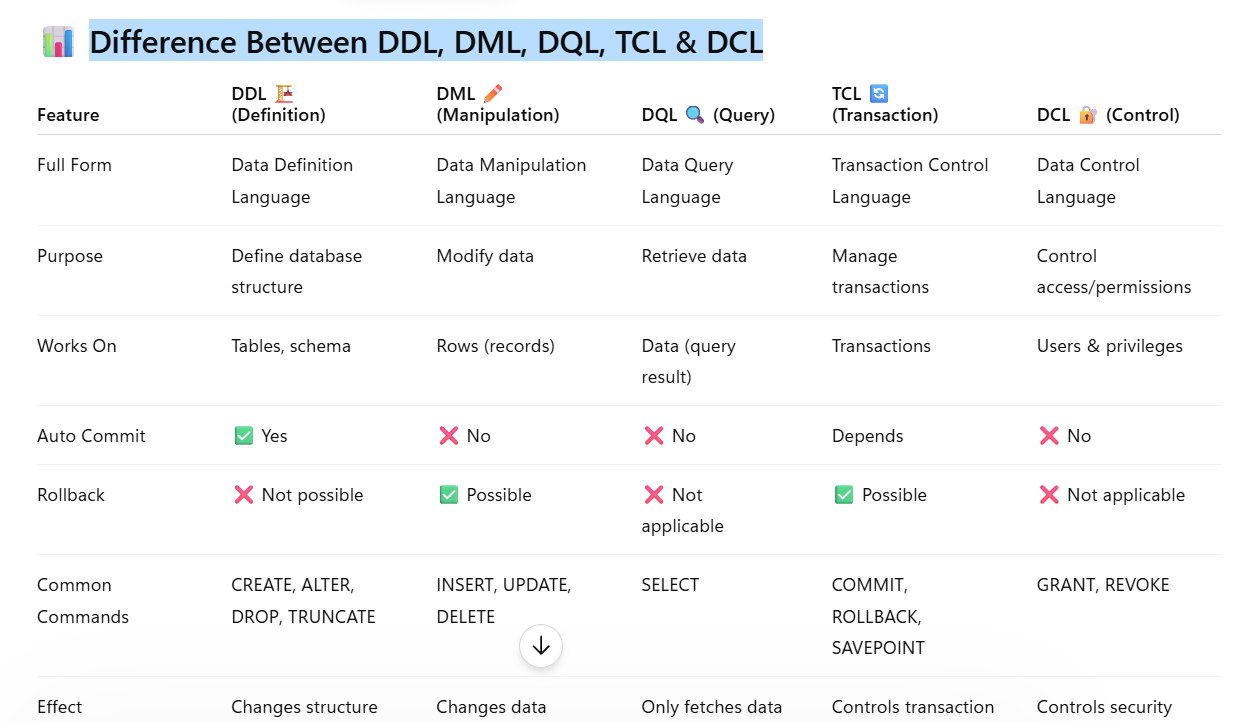

### Q. What are Window Functions in SQL?
- Window Functions perform calculations across a set of rows related to the current row (called a window), without collapsing rows like GROUP BY.
- **Types of Windows Functions**:-
    1. Ranking Functions.
    2. Aggregate Window Functions
    3. Value Functions
    4. Distribution Functions

1. **Ranking Functions**:- Used to assign ranks to rows.
    - 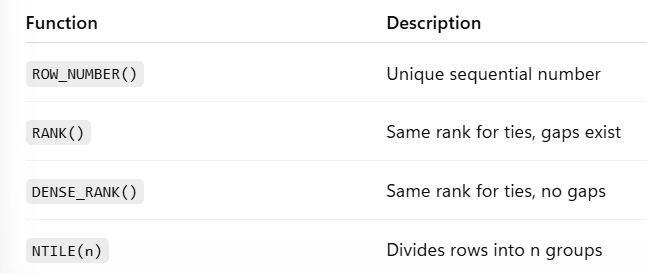
    - 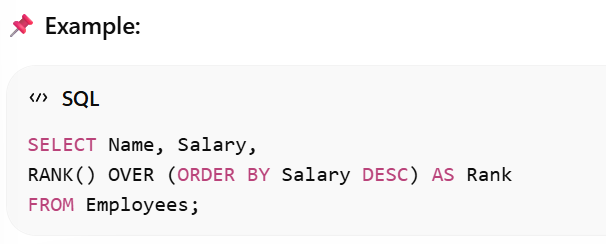
2. **Aggregate Window Functions**:- Similar to normal aggregate functions but work with window.
    - 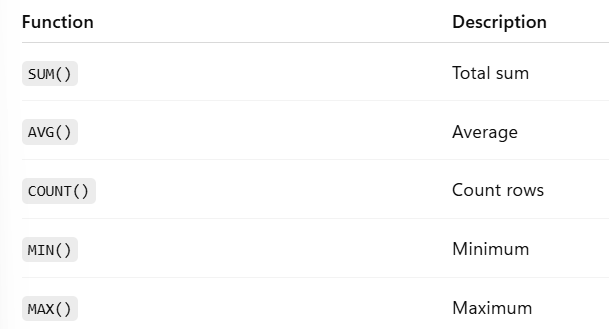
    - 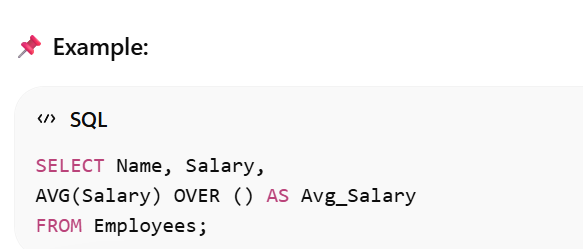
3. **Value Functions**:- Used to access values from other rows.
    - 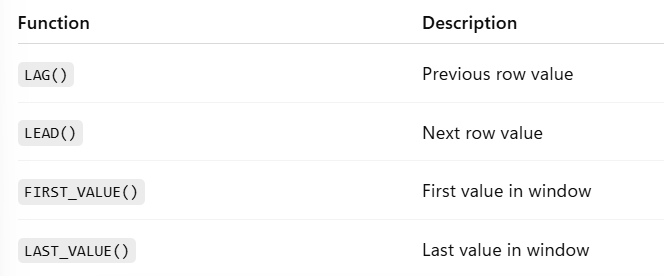
    - 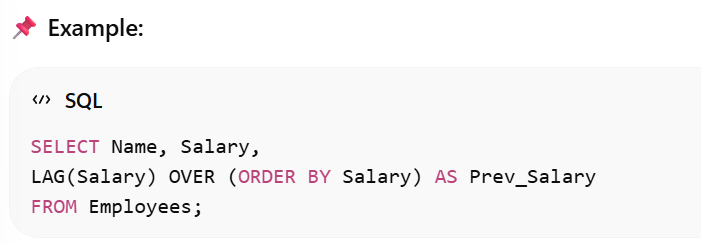
4. **Distribution Functions**:- Used for statistical distribution.
    - 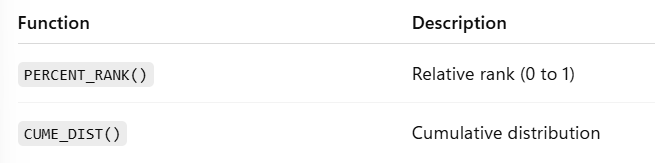

### Q. Find 2nd Highest Salary

In [ ]:
SELECT MAX(salary) FROM employees
WHERE salary < (SELECT MAX(salary) FROM employees);

In [ ]:
# By Using RANK function:-
SELECT salary FROM
(
    SELECT salary,
    RANK() 
    OVER (ORDER BY salary DESC) AS rnk
    FROM employees
) t
WHERE rnk = 2;

In [ ]:
# By using DENSE_RANK:-
SELECT salary FROM
(
    SELECT salary,
    DENSE_RANK() 
    OVER (ORDER BY salary DESC) AS rnk
    FROM employees
) t
WHERE rnk = 2;

In [ ]:
# By using Row_Number:-
SELECT salary FROM
(
    SELECT salary,
    ROW_NUMBER() 
    OVER (ORDER BY salary DESC) AS rn
    FROM employees
) t
WHERE rn = 2;

### Q. Find Duplicate Records

In [ ]:
SELECT name, COUNT(*) FROM employees
GROUP BY name
HAVING COUNT(*) > 1;

### Remove Duplicates:-

In [ ]:
DELETE FROM employees
WHERE id NOT IN (SELECT MIN(id) FROM employees
                 GROUP BY name );

### Q. Find Employees with Salary > Average Salary

In [ ]:
SELECT * FROM employees
WHERE salary > (SELECT AVG(salary) FROM employees);

### Q. Difference between Inner join, Left Join & Right Join

In [ ]:
# Inner Join
SELECT e.name, d.dept_name FROM employees e
INNER JOIN department d
ON e.dept_id = d.dept_id;

In [ ]:
# Left Join
SELECT e.name, d.dept_name FROM employees e
LEFT JOIN department d
ON e.dept_id = d.dept_id;

In [ ]:
# Right Join
SELECT e.name, d.dept_name FROM employees e
RIGHT JOIN department d
ON e.dept_id = d.dept_id;

### Difference between Inner Join, Left Join & Right Join
- 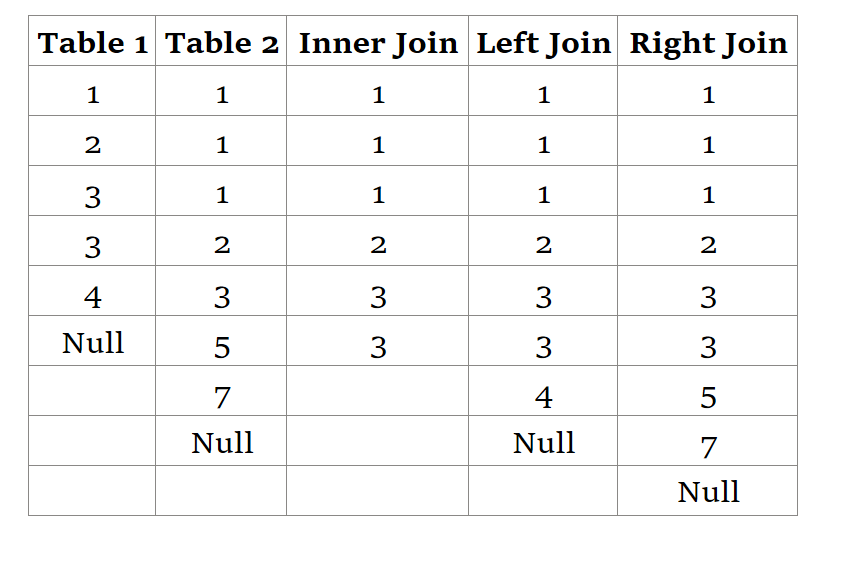

### Rank employees by using window functions:-

In [ ]:
SELECT name, salary,
RANK() 
OVER (ORDER BY salary DESC) AS rank
FROM employees;

### Q. Find Departments with Highest Avg Salary?

In [ ]:
SELECT dept_id, AVG(salary) FROM employees
GROUP BY dept_id
ORDER BY AVG(salary) DESC;

### Top 3 Salaries:-

In [ ]:
SELECT * FROM(
    SELECT name, salary,
    DENSE_RANK()
    OVER(ORDER BY salary DESC) AS rnk
    FROM employees)t
WHERE rnk <= 3;

### Highest salary per Department:-

In [ ]:
SELECT * FROM(
    SELECT name, department, salary,
    ROW_NUMBER()
    OVER(PARTITION BY department ORDER BY salary DESC) AS rn
    FROM employees)t
WHERE rn = 1;

### Employees with same salary(Duplicates)

In [ ]:
SELECT salary, COUNT(*)
FROM employees
GROUP BY salary
HAVING COUNT(*) > 1;

### Q. How to remove duplicate rows?

In [ ]:
DELETE FROM employees
WHERE rowid NOT IN(
    SELECT MIN(rowid)
    FROM employees
    GROUP BY name, salary);

### Q. Find Employees Earning more than Average salary.

In [ ]:
SELECT * FROM employees
WHERE salary > (SELECT AVG(salary) FROM employees);

### Q. Find 3rd Highest salary without window function?

In [ ]:
SELECT MAX(salary) FROM employees
WHERE employees 
WHERE salary < (
    SELECT MAX(salary) FROM employees
    WHERE salary < ( SELECT MAX(salary) FROM employees)
                   );    

### Q. Rank Employees by salary

In [ ]:
SELECT name, salary,
RANK ()
OVER (ORDER BY salary DESC) rnk
FROM employees;

### Find Highest salary by using subquery

In [ ]:
SELECT MAX(salary) FROM employees:

### Count Employees in each department

In [ ]:
SELECT department, count(*)
FROM employees
GROUP BY department;

### Q. Differentiate between Unique key, primary key & Foreign Key?

### 1. Unique Key:-
- A Unique Key ensures all values in a column are unique.
- **Key Features**:-
    1. No duplicate values allowed.
    2. NULL values allowed (usually one NULL, DB-dependent)
    3. Can have multiple unique keys in a table

In [ ]:
# Unique Key Example:-
CREATE TABLE Student 
(
  Email_id VARCHAR2(50) UNIQUE,
  Username VARCHAR2(50) UNIQUE
);

SELECT * FROM Student;

### 2. Primary Key:-
- A Primary Key uniquely identifies each record in a table.
- **Key Features**:-
    1. No duplicate values allowed.
    2. NULL values NOT allowed.
    3. Only one primary key per table.
    4. Automatically creates a clustered index (in many DBs)

In [ ]:
# Primary Key -> Example
CREATE TABLE Student 
(
  Student_id Number Primary Key,
  Name VARCHAR2(50)
);

SELECT * FROM Student;

### 3. Foreign Key:-
- A Foreign Key is used to link two tables.
- **Key Features**:-
    1. Refers to Primary Key (or Unique Key) in another table.
    2. Allows duplicate values.
    3. Can contain NULL values.
    4. Maintains referential integrity.

In [ ]:
# Foreign Key -> Example
CREATE TABLE Orders 
(
  OrderID INT PRIMARY KEY,
  CustomerID INT,
  FOREIGN KEY (CustomerID) REFERENCES Customers(ID)
);

### Q. What is the use of coalesce in SQL?
- COALESCE is a function used to return the first non-NULL value from a list of expressions.
- It checks values from left to right and returns the first value that is NOT NULL.

In [ ]:
# Example:-
SELECT COALESCE(NULL, NULL, 'Hello', 'World');

# Output ==> Hello

### Null Vs IS Null in SQL
- **Null**:- The NULL value represents a missing unknown data.
- **IS Null**:- IS NULL operator is used with the WHERE clause to TESTS FOR EMPTY (NULL) VALUES.

In [ ]:
# Null -> Example
SELECT * FROM Employees
WHERE salary = NULL;

In [ ]:
# IS null -> Example
SELECT * FROM Employees
WHERE AGE IS NULL;

### Q. Differentiate between Drop, Delete & Truncate
1. **DELETE** → Remove some data i.e. 1 row / 1 record.
    - DELETE From Employees WHERE E_name = 'John';
2. **TRUNCATE** → Remove all data quickly without its schema / structure.
    - TRUNCATE TABLE Employees;
3. **DROP** → Remove entire table.
    - DROP TABLE Employees;

- 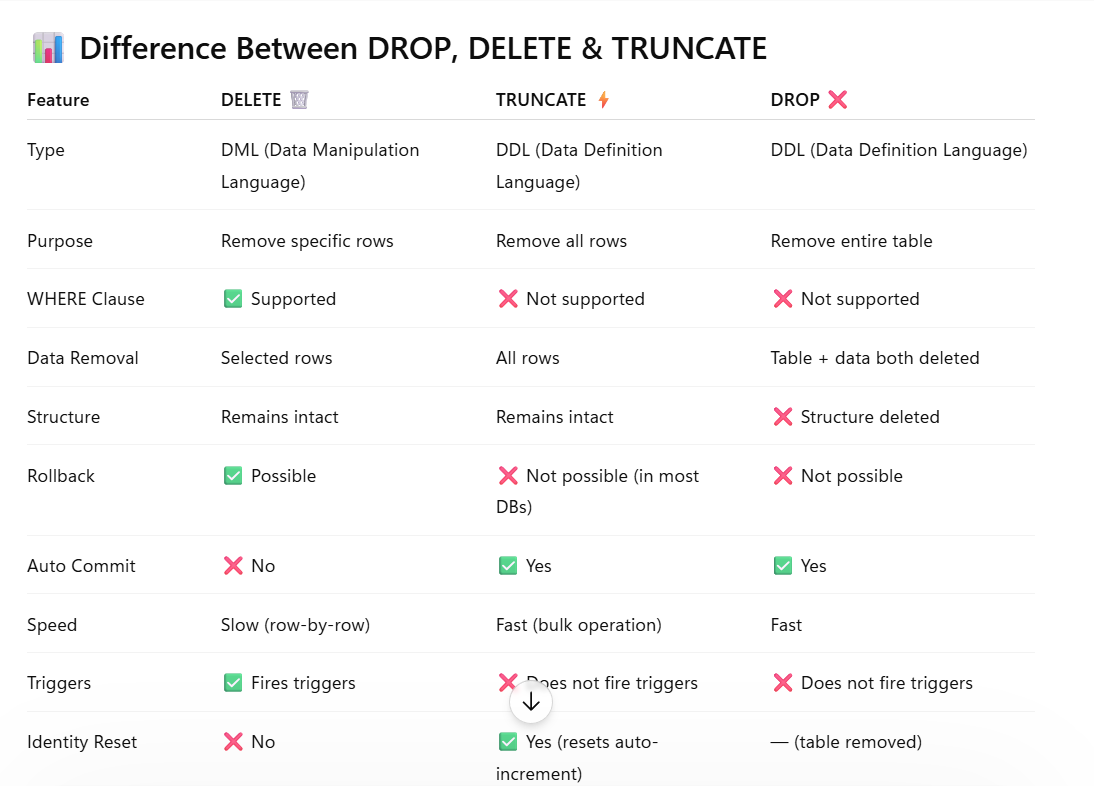

### Q. Difference between WHERE and HAVING Clause?
1. **Where**:- The WHERE clause is used to FILTERS RECORDS before calculation.
    - 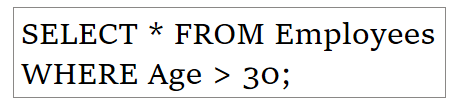
2. **Having**:- The HAVING clause is used to FILTERS RECORDS after calculation. The HAVING clause was added to SQL because the WHERE keyword could not be used with aggregate functions.
    - 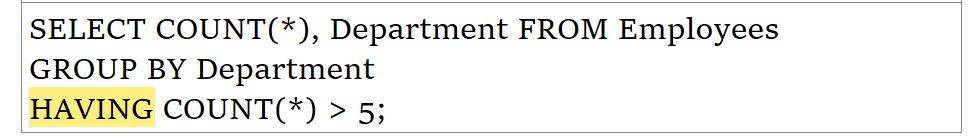

- 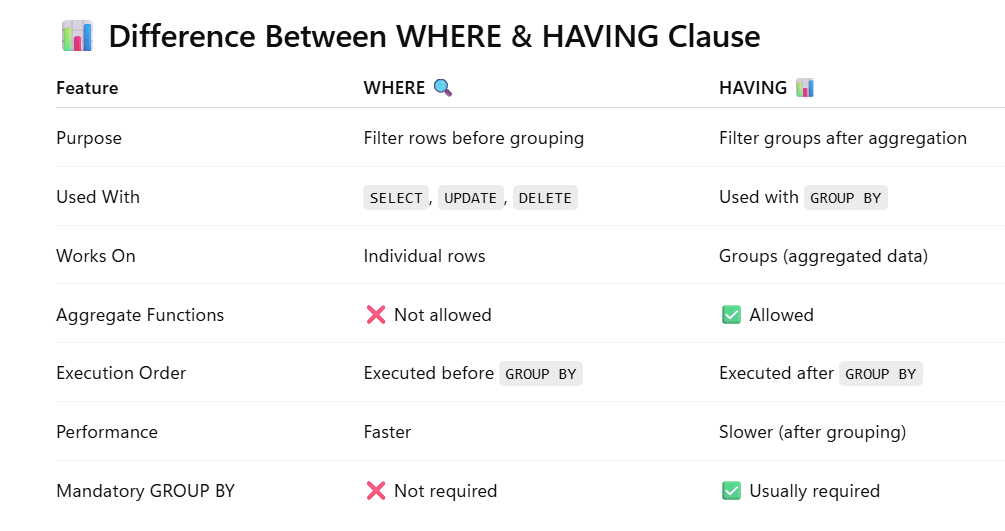

### Q. Difference between query, subquery & corelated subquery?
1. **Query** → Normal SQL Query.
    - Example:- SELECT * FROM Employees;
2. **Subquery** → Query inside query (Here inner query runs first)
    - 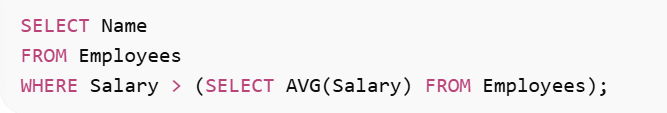
3. **Correlated Subquery** → Depends on outer query (row-by-row)
    - 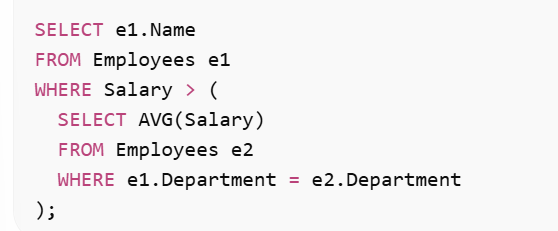

### Q. What are ACID Properties in SQL?
- ACID properties ensure that database transactions are reliable, consistent, and safe, especially in systems like banking, e-commerce, etc.
- ACID stands for:-
    - A → Atomicity
    - C → Consistency
    - I → Isolation
    - D → Durability

1. **Atomicity** = All or Nothing
    - If money is transferred from A → B
        - Debit successful but credit failed → rollback
        - Either both happen or none.
2. **Consistency** = Correct Data
    - After transaction:-
        - Account balance should not become invalid
        - Rules (like constraints) must be followed
3. **Isolation** = No Conflict
    - Two users updating same data:- One transaction should not see incomplete data of another.
4. **Durability** = Permanent Save
    - Once transaction is committed:- Data will not be lost even if system crashes.
    
- 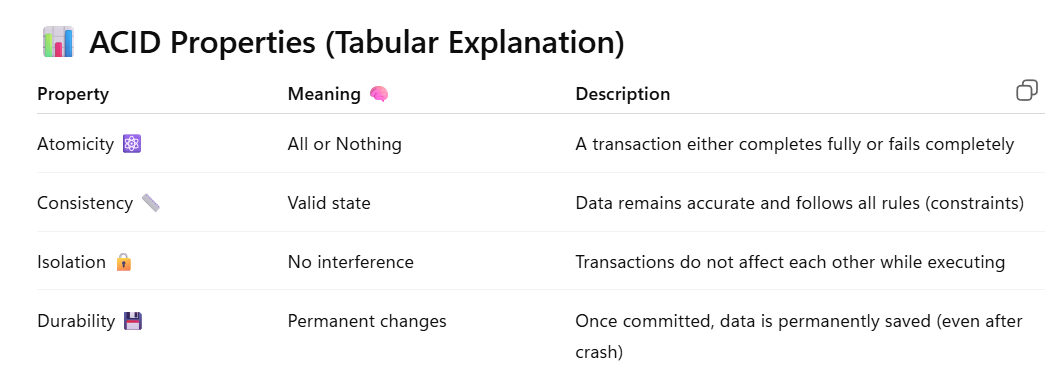

### Q. What is Normalization in SQL?
- **Normalization** = Breaking a large table into smaller related tables.
while maintaining relationships between them.
- Normalization is the process of organizing data in a database to:
    - Reduce redundancy (duplicate data)
    - Improve data integrity
    - Avoid anomalies (insert, update, delete issues)

- 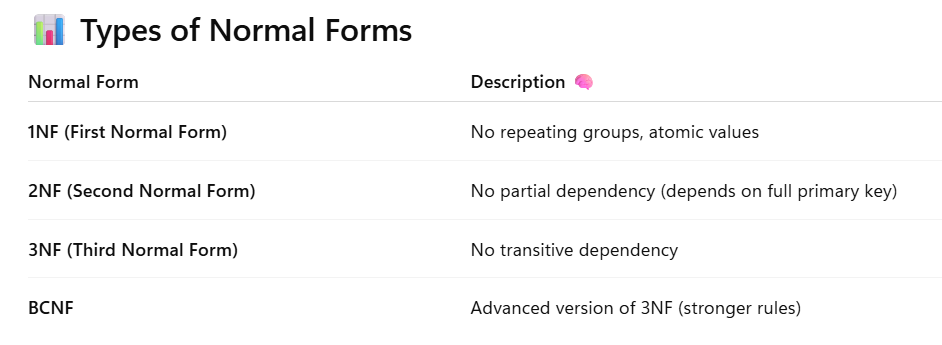

### Q. Write an SQL query to find the average salary for each department in a company table, but only for departments with more than 10 employees.
- This query calculates the average salary by department but only for those departments that have more than 10 employees, using HAVING to filter the groups.

In [ ]:
SELECT department, AVG(salary) AS avg_salary 
FROM employees 
GROUP BY department 
HAVING COUNT(employee_id) > 10;

### Q. Write an SQL query to find all employees whose salary is greater than the average salary in the employees table.
- The subquery (SELECT AVG(salary) FROM employees) calculates the average salary, and the outer query retrieves all employees earning more than that average.

In [ ]:
SELECT * FROM employees
WHERE salary > (SELECT AVG(salary) FROM employees);

### Q. What is a CTE in SQL?
- CTE (Common Table Expression) is a temporary result set that you can define and use within a query to make complex SQL easier to read and manage.
- **Key Points**:-
    - Defined using the WITH keyword.
    - Exists only during the execution of the query.
    - Improves readability and modularity
    - Can be referenced multiple times in the same query.
      
- 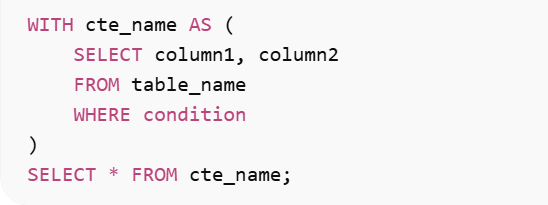
- 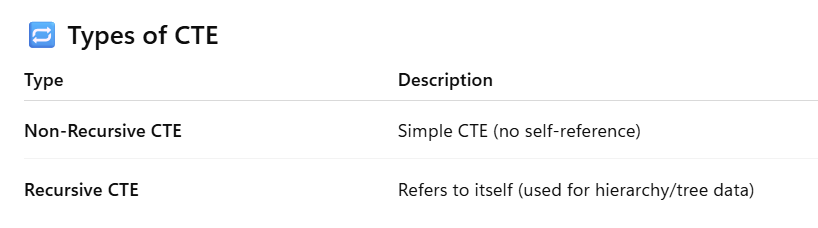
- 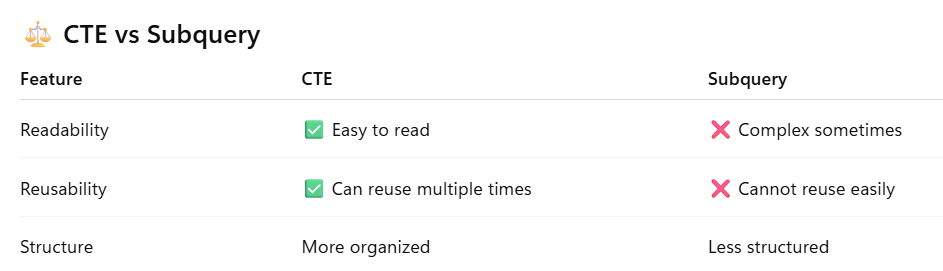

## Python Interview Questions:-

### Q. Difference between Shallow copy & Deep copy?

### Ans:- 
- The difference between shallow copy and deep copy mainly comes down to how they handle nested (inner) objects.
- 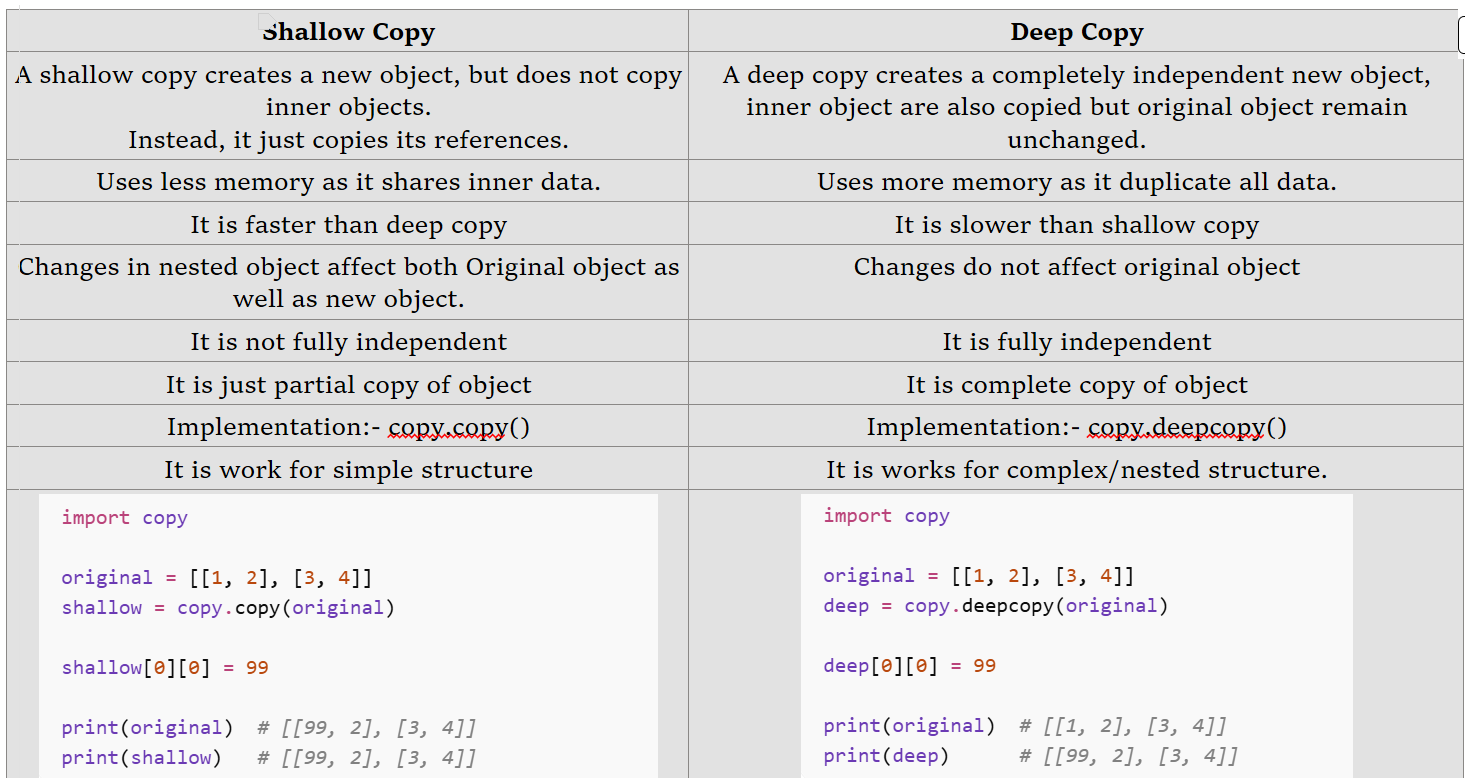

### Q. What is the difference between deepcopy() and copy() in Python
- The difference between copy() and deepcopy() in Python lies in how they handle nested (compound) objects like lists of lists or objects containing other objects.
    - **copy()** creates a shallow copy. It creates a new object, but only copies references of nested objects, changes made to nested (mutable) objects affect both the original and the copy.
    - **deepcopy()** creates a deep copy. It creates a new object and recursively copies all nested objects, changes to nested objects in the copy do not affect the original.

In [75]:
import copy

original = [[1, 2], [3, 4]]
shallow = copy.copy(original)
deep = copy.deepcopy(original)

original[0][0] = 99

print(shallow)  
print(deep)

[[99, 2], [3, 4]]
[[1, 2], [3, 4]]


### Q. How to reverse a list?

In [1]:
# By using Slicing method:-
L = [1,2,3,4,5]
rev = L[::-1]
print(rev)

[5, 4, 3, 2, 1]


In [2]:
# By using reverse method:-
L = [1,2,3,4,5]
rev = list(reversed(L))
print(rev)

[5, 4, 3, 2, 1]


In [6]:
# By using loop:-
L = [1,2,3,4,5]
rev = []    # empty list

for i in L:
    rev = [i] + rev
print(rev) 


[5, 4, 3, 2, 1]


### Q. How to fetch prime number from 1 to 100?

In [10]:
# By using loop:-
for num in range(1, 101):
    if num > 1:
        for i in range(2, num):
            if num % i == 0:
                break
        else:
            print(num, end=" ")

2 3 5 7 11 13 17 19 23 29 31 37 41 43 47 53 59 61 67 71 73 79 83 89 97 

### Q. differentiate between list, tuple, set , dictionary?
- **Quick Summary**:-
    - **List** → Mutable, ordered, allows duplicates.
    - **Tuple** → Immutable, ordered, allows duplicates, faster.
    - **Set** → Mutable, Unordered, not allows duplicates
    - **Dictionary** → Mutable, ordered, Key-value pairs, Keys are unique but values can be repeated (duplicate values are allowed)

- 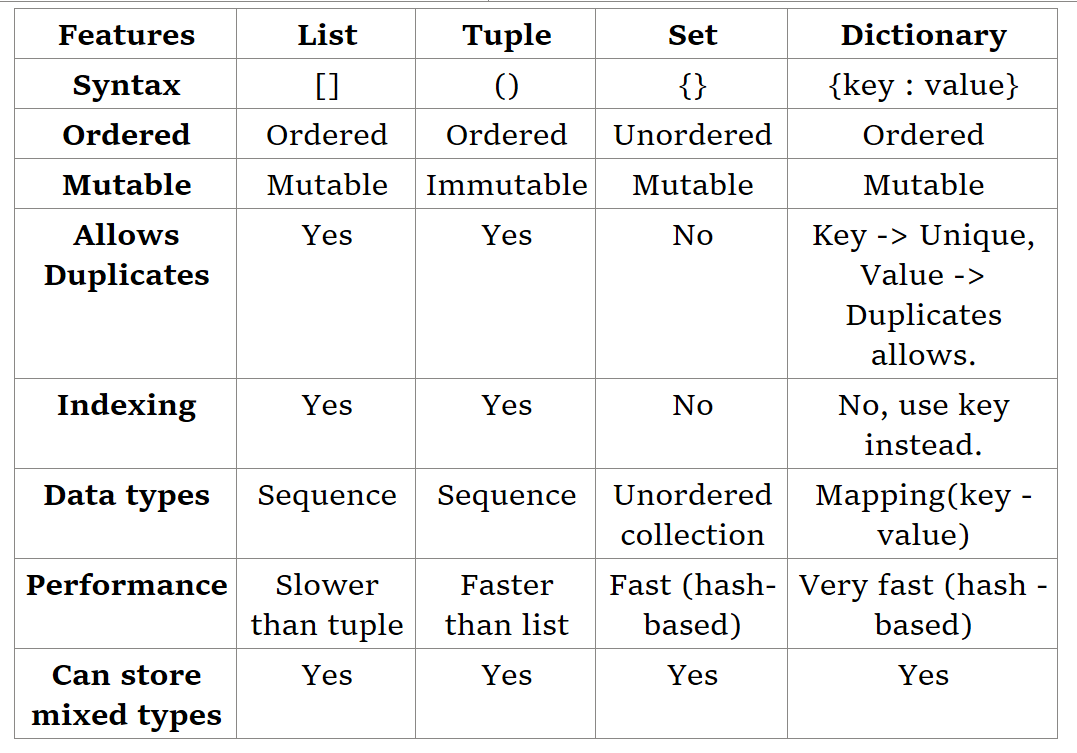

### Q. How can you concatenate two lists in Python?
We can concatenate two lists in Python using the +operator or the extend() method.

In [49]:
# Using the + Operator:-
# This creates a new list by joining two lists together.

a = [1, 2, 3]
b = [4, 5, 6]
res = a + b
print(res)

[1, 2, 3, 4, 5, 6]


In [50]:
# By using extend() method:-

a = [1, 2, 3]
b = [4, 5, 6]
a.extend(b)
print(a)

[1, 2, 3, 4, 5, 6]


### Q. What is list comprehension in python?
- List Comprehension in Python is a short and readable way to create lists in a single line using a loop.
- It is faster than traditional loop methods.
- Syntax:- [expression for item in iterable if condition]

In [11]:
# For finding squares of a list
L = [1,2,3,4,5]

squares = [i*i for i in L]
print(squares)

[1, 4, 9, 16, 25]


In [12]:
# for fetching even numbers:-
even_numbers = [i for i in range(10) if i % 2 == 0]
print(even_numbers)

[0, 2, 4, 6, 8]


### Nested List Comprehension:-
- A nested list comprehension means using a loop inside another loop within a single line to create complex lists (like matrices or combinations).
- Basic Syntax:- [expression for item1 in iterable1 for item2 in iterable2]
- Equivalent to:-
    - for item1 in iterable1:
         - for item2 in iterable2:
             - expression

In [13]:
matrix = [[1, 2, 3], [4, 5, 6]]

result = [num for row in matrix for num in row]
print(result)

[1, 2, 3, 4, 5, 6]


### Q. Is Python a compiled language or an interpreted language?
- Python is both compiled and interpreted —> but it’s usually described as an interpreted language.
- Python is an interpreted language, but internally it first compiles code into bytecode and then executes it using the Python Virtual Machine.

- How Python actually works:-
    - Compilation step (hidden):- Your .py code is first compiled into bytecode (.pyc files)
    - Interpretation step:- The bytecode is executed by the Python Virtual Machine (PVM).

- 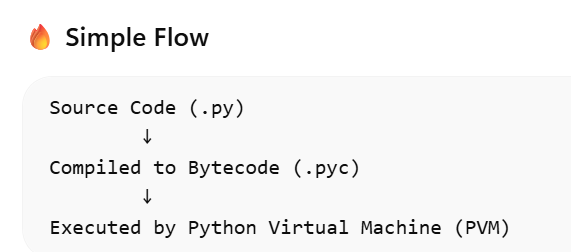

- Why it's called “Interpreted”:-
    - You don’t manually compile code like in languages such as C or C++
    - Execution happens line by line at runtime
    - No separate compilation step required by the user

### Q. Difference between for loop and while loop in Python?
- **For loop**: Used when we know how many times to repeat, often with lists, tuples, sets, or dictionaries.

- **While loop**: Used when we only have an end condition and don’t know exactly how many times it will repeat.

In [52]:
for i in range(5):
    print(i)

0
1
2
3
4


In [54]:
i = 0
while i < 5:
    print(i)
    i += 1

0
1
2
3
4


### Q. What is the difference between / and // in Python?
- / represents precise division (result is a floating point number) whereas // represents floor division (result is an integer i.e. Quetients).

In [55]:
print(5//2)
print(5/2)

2
2.5


### Q. Why indentation is important in Python?
- Indentation means spaces or tabs used at the beginning of a line to define a block of code.
- In Python, indentation is mandatory (not optional like many other languages).

- **Why Indentation is Important in Python**:-
    - Defines code blocks (instead of { })
    - Improves readability
    - Required for correct execution

In [56]:
if True:
    print("Hello")   # indented
    print("Python")

print("Outside block")

Hello
Python
Outside block


### Q. Can we Pass a function as an argument in Python?
- Yes, you can pass a function as an argument in Python. This works because functions are first-class citizens (objects) in Python.
- Several arguments can be passed to a function, including objects, variables (of the same or distinct data types) and functions.
- Functions can be passed as parameters to other functions because they are objects.
- Higher-order functions are functions that can take other functions as arguments.

- **Key Idea**:- A function can be:
    - Stored in a variable.
    - Passed as an arguments
    - Returned from another function

In [58]:
# The add function is passed as an argument to apply_func, 
# which applies it to 3 and 5.

def add(x, y):
    return x + y

def apply_func(func, a, b):
    return func(a, b)

print(apply_func(add, 3, 5))

8


In [59]:
def square(x):
    return x * x

def apply(func, value):
    return func(value)

print(apply(square, 4))

16


### Q.  What is a dynamically typed language?
- In a dynamically typed language, the data type of a variable is determined at runtime, not at compile time.
- No need to declare data types manually; Python automatically detects it based on the assigned value.
- Examples of dynamically typed languages: Python, JavaScript.
- Examples of statically typed languages: C, C++, Java.
- Dynamically typed languages are easier and faster to code.
- Statically typed languages are usually faster to execute due to type checking at compile time.

In [62]:
x = 10       # x is an integer
print(x)

x = "Hello"  # Now x is a string
print(x)

10
Hello


### Q. What is a break, continue and pass in Python?
- 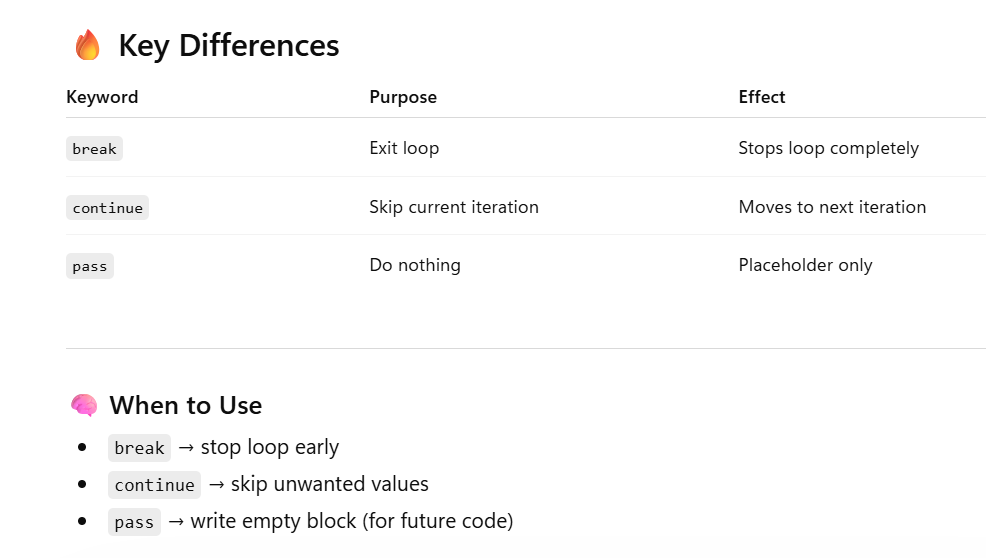

1. **break**:- break is used to exit the loop immediately.

In [69]:
for i in range(1, 6):
    if i == 3:
        break
    print(i)

1
2


### 2. continue:-
- continue is used to skip the current iteration and move to the next one.

In [71]:
for i in range(1, 6):
    if i == 3:   # skip only 3 here
        continue
    print(i)

1
2
4
5


### 3. pass:- 
- The pass statement is a placeholder that does nothing.
- It is used when a statement is syntactically required but no code needs to run.
- Commonly used when defining empty functions, classes or loops during development.

In [72]:
for i in range(1, 6):
    if i == 3:
        pass
    print(i)

1
2
3
4
5


In [64]:
def fun():
    pass  # Placeholder, no functionality yet

# Call the function
fun()

# Here, fun() does nothing, 
# but the code stays syntactically correct.

### Q. How are arguments passed by value or by reference in Python?
- Python’s argument-passing model is neither “Pass by Value” nor “Pass by Reference” but it is “Pass by Object Reference”.
- Depending on the type of object you pass in the function, the function behaves differently. Immutable objects show “pass by value” whereas mutable objects show “pass by reference”.

In [65]:
def call_by_val(x):
    x = x * 2
    return x


def call_by_ref(b):
    b.append("D")
    return b


a = ["E"]
num = 6

# Call functions
updated_num = call_by_val(num)
updated_list = call_by_ref(a)

# Print after function calls
print("Updated value after call_by_val:", updated_num)
print("Updated list after call_by_ref:", updated_list)

Updated value after call_by_val: 12
Updated list after call_by_ref: ['E', 'D']


### Q. What is a lambda function?
- A lambda function is an anonymous function. This function can have any number of parameters but, can have just one line expression.
- Syntax:- lambda arguments: expression

In [66]:
# For squares of any numbers
square = lambda x: x * x
print(square(4))

16


### Q. How are lambda functions used with map(), filter(), and reduce()? Give examples.
- How are lambda functions used with map(), filter(), and reduce()? Give examples.
1. map(function, iterable): Applies a function to every item in an iterable. 

In [78]:
nums = [1, 2, 3, 4]
squares = list(map(lambda x: x**2, nums))
# Output: [1, 4, 9, 16]
print(squares)

[1, 4, 9, 16]


In [79]:
# 2. filter(function, iterable): Filters items for which the function returns True.

nums=[1,2,3,4,5]
evens = list(filter(lambda x: x % 2 == 0, nums))
# Output: [2, 4]
print(evens)

[2, 4]


In [80]:
# 3. (function, iterable): Applies a rolling computation (from functools).

from functools import reduce
nums={2,4,6,2,8,5}
total = reduce(lambda x, y: x + y, nums)
# Output: 25
print(total)

25


### Q. Can lambda functions return multiple values? Explain with an example.
- Can lambda functions return multiple values? Explain with an example.
- Although lambdas don’t use the return keyword, the result of the expression is returned implicitly. You can use lambdas to quickly return combinations of values, such as sum and product, min and max, etc.

In [81]:
f = lambda x, y: (x + y, x * y)
result = f(3, 4)
print(result)  # Output: (7, 12)

(7, 12)


### Q. What are *args and **kwargs?
- *args: The special syntax *args in function definitions is used to pass a variable number of arguments to a function. Python program to illustrate *args for a variable number of arguments.
- **kwargs: The special syntax **kwargs in function definitions is used to pass a variable length argument list. We use the name kwargs with the double star **. Here **Kw means keyword arguments.

In [67]:
def fun(*args):
    for arg in args:
        print(arg)

fun('Hello', 'Welcome', 'to', 'GeeksforGeeks')

Hello
Welcome
to
GeeksforGeeks


In [68]:
def fun(**kwargs):
    for k, val in kwargs.items():
        print("%s == %s" % (k, val))


# Driver code
fun(s1='Geeks', s2='for', s3='Geeks')

s1 == Geeks
s2 == for
s3 == Geeks


### Q. What are Modules and Packages in Python?
- A module is a single file that contains Python code (functions, variables, classes) which can be reused in other programs. You can think of it as a code library. For example: math is a built-in module that provides math functions like sqrt(), pi, etc.
- package is a collection of related modules stored in a directory. It helps in organizing and grouping modules together for easier management. For example: The numpy package contains multiple modules for numerical operations.
- To create a package, the directory must contain a special file named __init__.py.

### Q. What are Decorators?
- Decorators are a powerful and flexible way to modify or extend the behavior of functions or methods, without changing their actual code.
- A decorator is essentially a function that takes another function as an argument and returns a new function with enhanced functionality.
- Decorators are often used in scenarios such as logging, authentication and memorization, allowing us to add additional functionality to existing functions or methods in a clean, reusable way.

### Q.  What are Iterators in Python?
- In Python, iterators are used to iterate a group of elements, containers like a list. Iterators are collections of items and they can be a list, tuples, or a dictionary.
- Python iterator implements __itr__ and the next() method to iterate the stored elements. We generally use loops to iterate over the collections (list, tuple) in Python.

### Q. What are Generators in Python?
- In Python, the generator is a way that specifies how to implement iterators. It is a normal function except that it yields expression in the function. It does not implement __itr__ and __next__ method and reduces other overheads as well.
- If a function contains at least a yield statement, it becomes a generator. The yield keyword pauses the current execution by saving its states and then resumes from the same when required.

### Q. How is memory management done in Python?
- Python uses its private heap space to manage the memory.
- Basically, all the objects and data structures are stored in the private heap space.
- Even the programmer can not access this private space as the interpreter takes care of this space.
- Python also has an inbuilt garbage collector, which recycles all the unused memory and frees the memory and makes it available to the heap space.

## Q. What is a zip function?
- Python zip() function returns a zip object, which maps a similar index of multiple containers. It takes an iterable, converts it into an iterator and aggregates the elements based on iterables passed. It returns an iterator of tuples.
- **Syntax**:
    - zip(*iterables) 

### Q. What are Pickling and Unpickling?
- **Pickling**: The pickle module converts any Python object into a byte stream (not a string representation). This byte stream can then be stored in a file, sent over a network, or saved for later use. The function used for pickling is pickle.dump().
- **Unpickling**: The process of retrieving the original Python object from the byte stream (saved during pickling) is called unpickling. The function used for unpickling is pickle.load().

### Q. What is OoP's in Python?
- OoP's is a programming approach where we model real-world entities using objects and classes.
- The main power of OoP is that, it gives programmer the power to create his own data types.
- OoP's is a programming paradigm based on the concept of "object" that can contain data and functions. Objects contain both data and methods that operate on that data.
- OoP's helps programmers organize code in a structured and reusable way.
- The four main principles of OoP's are Encapsulation, Inheritance, Polymorphism, and Abstraction.
- Python’s OOP has some unique features:-
    1. **Dynamic Typing**: Python classes and objects don’t require explicit type declarations.
    2. **Everything is an object in Python**: Even basic data types (like integers, functions) are objects with attributes and methods.

### Brief IMP Points on OoP's:-
- **Famous Line in Python** -> everything in python is an object.
- **The main power of OoP** is that, it gives programmer the power to create his own data types.
- **Method**:- A method is a function defined inside a class. They describe the behaviour of the object. Methods usually take self as the first parameter which represents the current instance of the class.
- **Function**:- A function is a block of reusable code defined outside a class.
- **Self-Keyword**:-
    - The self-keyword represents the current object ( instance) of the class.
    - It is used to access variables and methods inside the class.
    - 'self' is instance of class, because object is instance of class.
    - 'self' is nothing but current object, Then why we use self because golden rule of OoP's is that only object will call methods or attributes which written inside the class.
    - We need to communicate with each other inside the class, it is possible indirectly through self.
- **Aggregation** is a “Has-A” relationship where one class contains another class object but both can exist independently.
- **super()** is an inbuilt function which is used to invoke the parent class methods and constructor.
- **Method Overriding**:- Method overriding occurs when a child class provides a specific implementation of a method that is already defined in its parent class.
- **Method Overloading** is a concept where we can write more than 1 method inside a single class. method overloading does not work in python.
- **Operator Overloading**:- Operator overloading allows operators such as + or * to work differently with custom objects. This is achieved by defining special methods like __add__ in classes.

### 1. Class:- 
- It is a blueprint for creating an objects, defining their properties and methods.
- A class is a set of rules used to create objects, which follow those rules.

In [30]:
class Student:
    def __init__(self, name):
        self.name = name

### 2. Object:- 
- It is an instance of Class.
- Once a class is defined, we can create multiple objects from it.
- Each object can have its own data while sharing the same methods defined in the class.
- Objects represent real-world entities such as a student, employee, or car.
- Objects are created by calling the class name as if it were a function, passing the required arguments.

In [31]:
class Student:
    def __init__(self, name):
        self.name = name

s1 = Student("Rahul")
print(s1.name)

Rahul


### Constructor (__init__):- 
- A constructor is a special method used to initialize objects when they are created.
- It automatically runs when a new object is created from a class.
- It is a function inside the class.
- constructor is a special function -> because iske pass ek superpower hai.
- In Python, the constructor method is called __init__ method.
-  It is commonly used to assign values to object attributes.
-  Generally, we can write configuration-related code inside the constructor.

In [18]:
class Employee:
    def __init__(self, name, salary):
        self.name = name
        self.salary = salary

e1 = Employee("Rahul", 50000)

### Instance Variables vs Class Variables:-
1. **Instance Variables**:-
    - Instance variables are variables defined inside the constructor using self.
    - These variables belong to each object separately.
    - Each object can have different values for its instance variables.
    - They store the state of an object.

2. **Class Variables**:- A class variable is a variable that:
    - Is defined inside a class but outside methods.
    - Is shared by all objects (instances) of that class.
    - Has only one copy for the entire class.

In [19]:
class Test:
    x = 10   # class variable

    def __init__(self):
        self.y = 20   # instance variable

### Encapsulation:-
- Encapsulation means it binds data and code together into one unit.
- It also restricts direct access to some variables.
- In Python, this can be achieved using private variables with double underscores.

In [20]:
class Bank:
    def __init__(self):
        self.__balance = 1000   # private

    def show(self):
        print(self.__balance)

b = Bank()
b.show()

1000


### Inheritance:- 
- It allows one class to inherit properties and methods from another class.
- The class that inherits is called the child class, and the class being inherited from is called the parent class.
- **Types of Inheritance**:- Python supports single inheritance, multiple inheritance, multi-level inheritance, hierarchical inheritance, and hybrid inheritance.

In [21]:
class Parent:
    def show(self):
        print("Parent class")

class Child(Parent):
    pass

c = Child()
c.show()

Parent class


### Polymorphism:- 
- Polymorphism means many forms. Polymorphism means same function name with different behaviour.
- In programming, it refers to using the same function name with different implementations.
- Python supports polymorphism in functions and methods.

In [22]:
class Dog:
    def sound(self):
        print("Bark")

class Cat:
    def sound(self):
        print("Meow")

for obj in [Dog(), Cat()]:
    obj.sound()

Bark
Meow


### Abstraction:-
- Hiding internal details, showing only essential features.
- **Abstract Classes**:- Abstract classes are classes that cannot be instantiated directly. They are used as base classes for other classes. Python supports abstract classes through the abc module.

In [23]:
from abc import ABC, abstractmethod

class Shape(ABC):
    @abstractmethod
    def area(self):
        pass

class Circle(Shape):
    def area(self):
        print("Circle area")

### Types of Methods:-
1. Magic Method / Dunder Method
2. Instance Method
3. Class Method
4. Static Method

### 1. Magic Method / Dunder ( Double Underscore) Method:-
- Magic methods are special methods in Python that start and end with double underscores.
- They allow customization of object behavior, such as how objects are represented, compared, or used with operators.
- Examples include:-
    1. __init__:- Constructor method, called when an object is created.
    2. __str__:- Defines the string representation of an object.
    3. __len__:- Defines behavior for the len() function.
    4. __add__:- Enables operator overloading for +.

In [24]:
class Demo:
    def __str__(self):
        return "Hello"

d = Demo()
print(d)

Hello


### 2. Instance Method in Python:-
- Instance Method operates on an instance of the class and has access to instance attributes and takes self as the first parameter.

In [26]:
class Student:
    def __init__(self, name, marks):
        self.name = name
        self.marks = marks

    # Instance method
    def display(self):
        print("Name:", self.name)
        print("Marks:", self.marks)

# Creating object
s1 = Student("Rahul", 95)

# Calling instance method
s1.display()

Name: Rahul
Marks: 95


### 3. Class Method:- 
- Class Method directly operates on the class itself and not on instance, it takes cls as the first parameter and defined with @classmethod decorator.

In [28]:
class Student:
    school = "ABC School"   # class variable

    @classmethod
    def show_school(cls):
        print("School Name:", cls.school)

# Call using class
s1 = Student()
s1.show_school()

School Name: ABC School


### 4. Static Method:-
- Static Method does not operate on an instance or the class and takes no self or cls as an argument and is defined with @staticmethod.
- It’s used when logic is related to the class but doesn’t need class/object data.

In [29]:
class MathUtils:

    @staticmethod
    def add(a, b):
        return a + b

# Call using class
print(MathUtils.add(5, 3))

8


### Key Concepts Summary:-
- 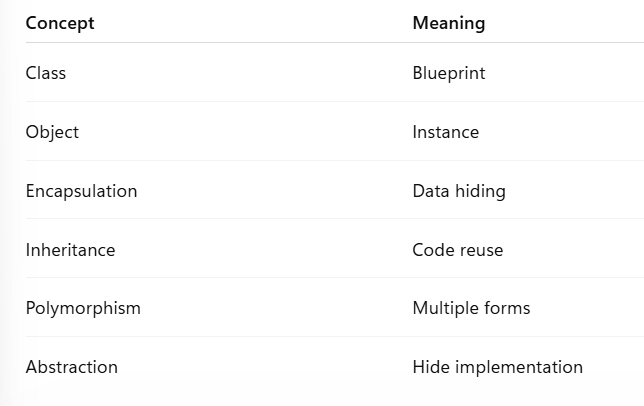

###  Q. What is the super() function in Python?
super() allows access to methods of the parent class and it’s often used to call the parent class’s constructor.

In [82]:
class A:
    def method(self):
        print("Method in class A")

class B(A):
    def method(self):
        super().method()  # Call method from class A
        print("Method in class B")

class C(A):
    def method(self):
        super().method()  # Call method from class A
        print("Method in class C")

### File Handling:-
- File handling means creating, reading, writing, and managing files (like .txt, .csv, etc.) using Python.
- It read data from a files & Store data permanently.
- Basic Steps:-
    1. Open a file
    2. Perform Operations(read/write)
    3. Close file
- 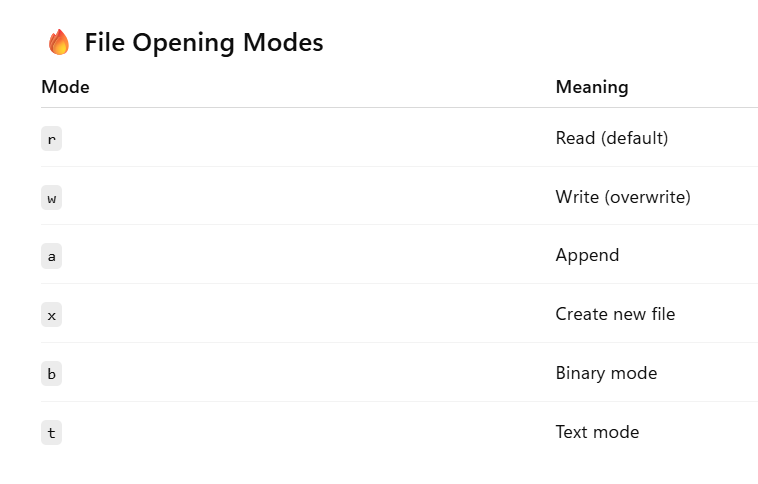
- 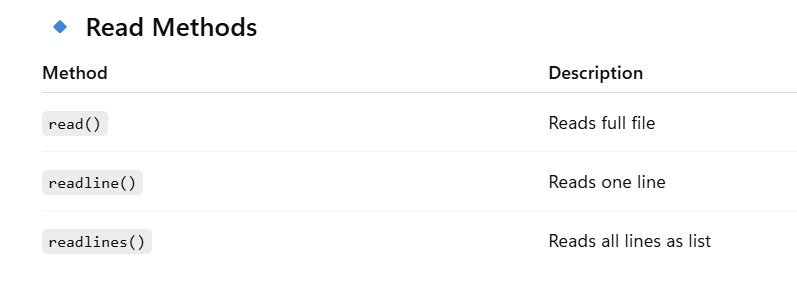

In [32]:
# 1. Write something in a file
f = open("demo.txt", "w")
f.write("Hello Python")
f.close()

In [33]:
# Read a file:-
f = open("demo.txt", "r")
data = f.read()
print(data)
f.close()

Hello Python


In [34]:
# Append the file:-
f = open("demo.txt", "a")
f.write("\nNew Line Added")
f.close()

In [35]:
# Using 'with':- Automatically closes file (no need for close())

with open("demo.txt", "r") as f:
    data = f.read()
    print(data)

Hello Python
New Line Added


### Exception handling in Python:-
- Exception handling is used to manage runtime errors and ensure smooth execution of a program without crashing it.
- 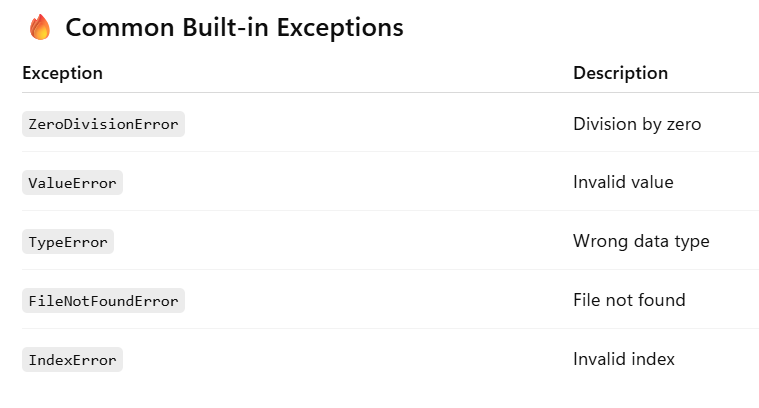 

In [ ]:
# Basic Syntax:-
try:
    # risky code
except:
    # code to handle error
finally:    
    # for cleanup

In [36]:
# Note:- If user enters 0 or invalid input → program won’t crash
try:
    a = int(input("Enter number: "))
    print(10 / a)
except:
    print("Error occurred")

Enter number:  2


5.0


In [37]:
# Multiple Exception:-
try:
    x = int("abc")
except ValueError:
    print("Invalid value")
except ZeroDivisionError:
    print("Divide by zero error")

Invalid value


In [38]:
# Using else -> Runs if no exception occurs

try:
    x = 10 / 2
except:
    print("Error")
else:
    print("Success:", x)

Success: 5.0


In [39]:
# Using finally -> Runs always (error or not)
try:
    f = open("file.txt")
except:
    print("File not found")
finally:
    print("Execution completed")

File not found
Execution completed


In [ ]:
# Raising Exception
age = -5
if age < 0:
    raise ValueError("Age cannot be negative")

In [ ]:
# Custom Exception:- 
class MyError(Exception):
    pass

raise MyError("Custom error occurred")

### Q. What is iterator, generator, decorator, nameplace, etc in python, explain it with examples.

### 1. Iterator:-
- An iterator is an object that:-
    - Can be iterated (looped) over
    - Implements __iter__() and __next__()
- It returns values one by one.
- An iterator is an object that allows you to traverse a collection of data (like a list or tuple) one element at a time.
- Technically, any object that implements the iterator protocol—> __iter__() and __next__() methods—> is an iterator.

- **How it works**: You get an iterator from an "iterable" (like a list) using iter(), and then use next() to get values until a StopIteration error is raised.

In [41]:
nums = [1, 2, 3]

it = iter(nums)   # create iterator

print(next(it))   # 1
print(next(it))   # 2
print(next(it))   # 3

1
2
3


In [46]:
my_list = [10, 20]
my_iter = iter(my_list) # Get iterator
print(next(my_iter))    # Output: 10
print(next(my_iter))    # Output: 20

10
20


### 2. Generator:-
- It automatically implements iterator.
- A generator is a special type of iterator:-
    - Uses yield instead of return
    - Generates values lazily (on demand)
- A generator is a simpler way to create an iterator using a function. Instead of return, a generator uses the yield keyword to produce a value and "pause" its execution, remembering its state for the next time it is called.

- **Why it is used?**:- They are highly memory-efficient because they generate values on the fly instead of storing a whole list in RAM.

In [43]:
# Generator expression:-
g = (i*i for i in range(5))
print(list(g))

[0, 1, 4, 9, 16]


In [42]:
def my_gen():
    for i in range(3):
        yield i

g = my_gen()

print(next(g))  # 0
print(next(g))  # 1
print(next(g))  # 2

0
1
2


In [48]:
def count_up_to(n):
    i = 0
    while i <= n:
        yield i
        i += 1

for num in count_up_to(2):
    print(num) # Prints 1, 2, 3

0
1
2


### 3. Decorator:-
- A decorator is a function that modifies another function without changing its code.
- A decorator is a function that takes another function as input, adds some extra behavior to it, and returns a new version of it.
- It allows you to modify a function's behavior without changing its actual source code.

In [44]:
def my_decorator(func):
    def wrapper():
        print("Before function")
        func()
        print("After function")
    return wrapper

@my_decorator
def say_hello():
    print("Hello")

say_hello()

Before function
Hello
After function


### 4. Nameplace:-
- A namespace is essentially a container (like a dictionary) that maps variable names to their actual objects that Stores variable names and their values & avoids name conflicts. It ensures that names are unique and don't conflict. 
- **Order of Search**:- Python follows **LEGB rule**: Local → Enclosing → Global → Built-in
- **Types**:-
    - **Built-in**: Names like print() and len().
    - **Global**: Names defined at the top level of a script or module.
    - **Local**: Names defined inside a function.      
- 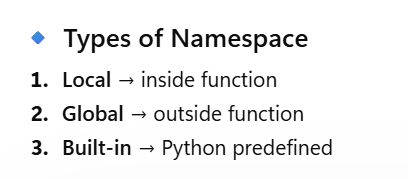

In [45]:
x = 10   # global

def func():
    x = 5   # local
    print(x)

func()
print(x)

5
10


### Quick Comparison:- 
- 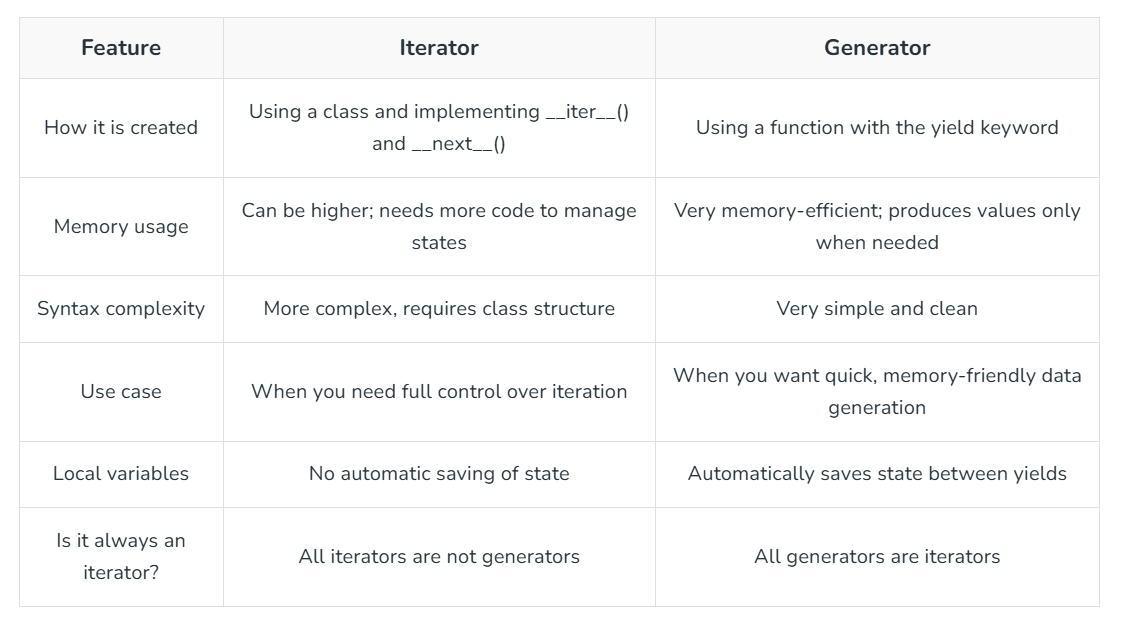
- 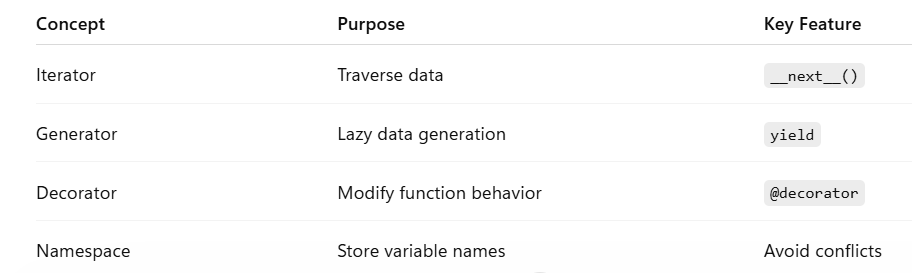

### Q. What is __init__() in Python and how does self play a role in it?
- __init__() is Python's equivalent of constructors in OOP, called automatically when a new object is created.
- It initializes the object's attributes with values but doesn’t handle memory allocation.
- Memory allocation is handled by the __new__() method, which is called before __init__().
- The self parameter in __init__() refers to the instance of the class, allowing access to its attributes and methods.
- self must be the first parameter in all instance methods, including __init__().

In [73]:
class MyClass:
    def __init__(self, value):
        self.value = value  # Initialize object attribute

    def display(self):
        print(f"Value: {self.value}")

obj = MyClass(10)
obj.display()

Value: 10


In [74]:
# Q. Write a code to display the current time?

import time

currenttime= time.localtime(time.time())
print ("Current time is", currenttime)

Current time is time.struct_time(tm_year=2026, tm_mon=4, tm_mday=20, tm_hour=17, tm_min=55, tm_sec=57, tm_wday=0, tm_yday=110, tm_isdst=0)


### Q. What is Garbage collection in Python?
- Garbage Collection (GC) is the process of automatically freeing memory by deleting objects that are no longer in use.
- It helps prevent memory leaks and manages memory efficiently.
- How Python Handles Memory:- Python mainly uses:
    1. Reference Counting:-
        - Every object has a reference count
        - When count becomes 0 → object is deleted   

In [76]:
# Reference Counting:- 
a = [1, 2, 3]
b = a   # reference count increases

del a   # reference count decreases
del b   # now count = 0 → object removed

In [77]:
# 2. Cyclic Garbage Collection:-
# Handles reference cycles (objects referring to each other)
# Reference counting alone can’t clean these

import gc

gc.collect()   # manually trigger garbage collection

797

### Q. What is the difference between pop() and popitem()?
- **pop()** removes a key-value pair by the key and returns its value.
- **popitem()** removes and returns a random key-value pair, typically used for arbitary removal.
- 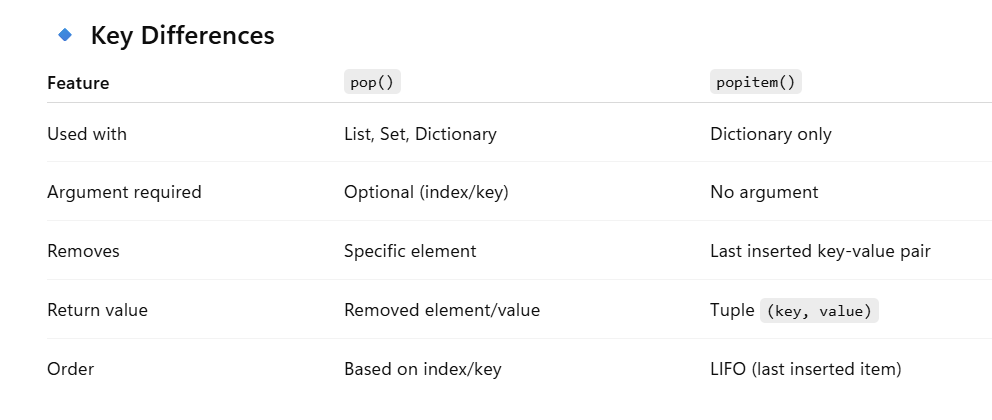
- 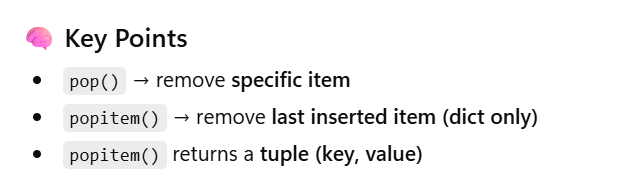

In [83]:
# pop():- List
nums = [10, 20, 30, 40]
nums.pop()        # removes last element
print(nums)

[10, 20, 30]


In [84]:
# pop():- Dictionary
d = {"a": 1, "b": 2}
d.pop("a")
print(d)

{'b': 2}


In [85]:
# popitem():- dictionary only
d = {"a": 1, "b": 2, "c": 3}
item = d.popitem()

print(item)
print(d)

('c', 3)
{'a': 1, 'b': 2}


### Q. Palindrome String in Python
- A palindrome is a string that reads the same forward and backward.
- Example: madam, racecar

In [86]:
s = input("Enter string: ")

if s == s[::-1]:
    print("Palindrome")
else:
    print("Not Palindrome")

Enter string:  madam


Palindrome


### Q. Write a function to find the first 5 number Fibonacci number using recursion.
- Each number = sum of previous two numbers
- Sequence: 0 1 1 2 3 ...

In [87]:
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

# Print first 5 Fibonacci numbers
for i in range(5):
    print(fib(i), end=" ")

0 1 1 2 3 

### Q. Write a Python function to calculate the factorial of a number.

In [88]:
def factorial(n):
    if n == 0 or n == 1:
        return 1
    return n * factorial(n - 1)

print(factorial(5))

120


### Q. How do you read and write data from a file in Python?
- To read and write data from file in Python, we use the built-in open() function, which provides a way to open a file and perform various operations on it, such as reading or writing.

In [90]:
# Writing a file
with open('file.txt', 'w') as file:
    file.write("Hello, world!")

In [91]:
# Reading a file
with open('file.txt', 'r') as file:
    content = file.read()
print(content)

Hello, world!


## Git & Github Interview Questions:-

### Q. What is Git?
- Git is a distributed version control system used to track changes in code. It is used for tracking code changes & tracking who made changes.
- 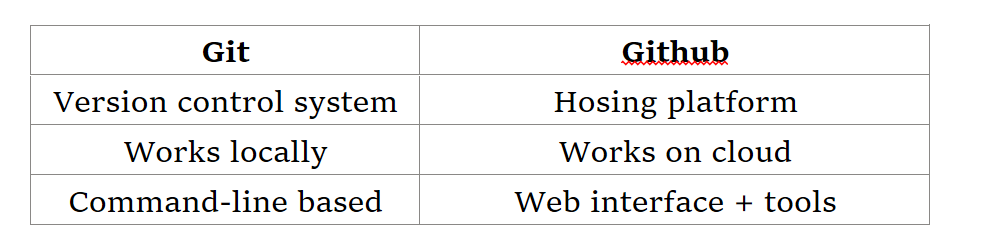

### Q. What is GitHub?
- Github is a cloud platform that uses Git. It helps you: Store your code online, Share code with others, Collaborate with teams & Backup your projects.

### Key Git Concepts:-
1. **Repository**: A folder where Git tracks your project and its history.
2. **Clone**: Make a copy of a remote repository on your computer.
3. **Stage**: Tell Git which changes you want to save next.
4. **Commit**: Save a snapshot of your staged changes.
5. **Branch**: Work on different versions or features at the same time.
6. **Merge**: Combine changes from different branches.
7. **Pull**: Get the latest changes from a remote repository.
8. **Push**: Send your changes to a remote repository.

### Q. What is a Repository?
- A Git repository is a folder that Git tracks for changes.
- The repository stores all your project's history and versions.

### Q. What is a Commit?
- A commit is like a save point in your project.
- git commit -m "your message"

### Q. What is a branch?
- A branch is a separate line of development (e.g., main, feature).

### Q. What is merging?
- Combining changes from one branch into another.

### Q. What is a pull request (PR)?
- A request to merge code from one branch to another (used in GitHub).

### Q. What is git clone?
- Copies a remote repository to local system.
- git clone <repo_url>

### Q. What is git push?
- Uploads local commits to remote repository.

### Q. What is git status?
- Shows current state of working directory.

### Q. What is git add?
- Adds files to staging area.

### Q. What is git rebase?
- Rewrites commit history for a cleaner linear history.

### Q. What is .gitignore?
- File used to ignore unwanted files (e.g., logs, temp files).

### Q. How to create a branch?
- git branch feature
- git checkout feature

### Q. What happens when you run git pull?
- git fetch + git merge